**Load regression data.** Load the regression-ready district dataset. It was already filtered to enrollment >= 100 and capped at the 99th percentile for per-pupil spending, so unstable small-denominator values and extreme spending values do not distort the models.


In [19]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_regression = pd.read_csv('../datasets/district_data_regression.csv',dtype={'LEAID': str,'FIPST':str,'SCHLEV':str})

print(df_regression.shape)
print(df_regression.columns.tolist())
df_regression.head()

(11984, 22)
['LEAID', 'STNAME', 'FIPST', 'LEANM', 'PCTPROF_MTH_clean', 'PCTPROF_RLA_clean', 'NUMVALID_MTH_clean', 'NUMVALID_RLA_clean', 'SCHLEV', 'MEMBERSCH', 'TOTALEXP', 'TOTALREV', 'TFEDREV', 'TSTREV', 'TLOCREV', 'TCURINST', 'TCURSSVC', 'TCAPOUT', 'per_pupil_exp', 'poverty_rate', 'Estimated Population 5-17', 'per_pupil_exp_capped']


,LEAID,STNAME,FIPST,LEANM,PCTPROF_MTH_clean,PCTPROF_RLA_clean,NUMVALID_MTH_clean,NUMVALID_RLA_clean,SCHLEV,MEMBERSCH,...,TFEDREV,TSTREV,TLOCREV,TCURINST,TCURSSVC,TCAPOUT,per_pupil_exp,poverty_rate,Estimated Population 5-17,per_pupil_exp_capped
0,0100005,ALABAMA,01,Albertville City,46.0,38.0,2911,2869,03,5636,...,7939000,36177000,16000000,28612000,17262000,2750000,9800.745209,30.053842,4086,9800.745209
1,0100006,ALABAMA,01,Marshall County,40.0,36.0,2952,2938,03,5652,...,7953000,40042000,13941000,30884000,23015000,266000,10619.603680,26.622181,8692,10619.603680
2,0100007,ALABAMA,01,Hoover City,70.0,65.0,7475,7442,03,13952,...,6935000,78790000,103399000,102547000,57484000,17371000,14019.853784,7.259553,14629,14019.853784
3,0100008,ALABAMA,01,Madison City,76.0,73.0,5903,5867,03,11290,...,6043000,69870000,53490000,65771000,38601000,4186000,10535.075288,8.298157,9713,10535.075288
4,0100011,ALABAMA,01,Leeds City,45.0,42.0,1063,1064,03,1950,...,1574000,12794000,6776000,10796000,7807000,221000,10995.897436,16.887608,1735,10995.897436


**Data check.** The prepared regression sample contains 11,984 districts and includes the two outcome measures, poverty rate, and capped per-pupil spending needed for the analysis. The data are ready for baseline modelling.


**Model A: Math proficiency regression.** Start with a baseline math model: after accounting for poverty, is per-pupil spending associated with math proficiency? This establishes the whole-sample relationship before making more detailed claims.


In [20]:
X_a = df_regression[['per_pupil_exp_capped', 'poverty_rate']]
X_a = sm.add_constant(X_a)  # adds the intercept term
y_a = df_regression['PCTPROF_MTH_clean']

model_a = sm.OLS(y_a, X_a, missing='drop').fit()
print(model_a.summary())

                            OLS Regression Results                            
Dep. Variable:      PCTPROF_MTH_clean   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     1877.
Date:                Thu, 13 Aug 2026   Prob (F-statistic):               0.00
Time:                        13:37:42   Log-Likelihood:                -49734.
No. Observations:               11984   AIC:                         9.947e+04
Df Residuals:                   11981   BIC:                         9.950e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   60.7696 

**Model A result.** Poverty is highly significant (coefficient = -0.944, p < 0.001) and explains most of the observed relationship. Capped per-pupil spending is not significant (p = 0.255). The model explains 23.9% of variation in math proficiency.


**Model B: Reading proficiency regression.** Model A found no average spending relationship for math. Test the same predictors against reading proficiency to see whether this conclusion holds across subjects or is specific to math.


In [21]:
X_b = df_regression[['per_pupil_exp_capped', 'poverty_rate']]
X_b = sm.add_constant(X_b)
y_b = df_regression['PCTPROF_RLA_clean']

model_b = sm.OLS(y_b, X_b, missing='drop').fit()
print(model_b.summary())

                            OLS Regression Results                            
Dep. Variable:      PCTPROF_RLA_clean   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.318
Method:                 Least Squares   F-statistic:                     2799.
Date:                Thu, 13 Aug 2026   Prob (F-statistic):               0.00
Time:                        13:37:42   Log-Likelihood:                -48094.
No. Observations:               11984   AIC:                         9.619e+04
Df Residuals:                   11981   BIC:                         9.622e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   65.1116 

**Model B result.** Poverty is again highly significant (coefficient = -0.991, p < 0.001). Spending has a statistically significant but practically small positive association (coefficient = +0.000063, p = 0.001). **The average spending relationship differs by subject:** none is detected for math, while reading has a small positive association.


**VIF diagnostic.** Both baseline models include spending and poverty together, and their summaries show a high condition number. Check VIF to determine whether the predictors are genuinely too correlated to separate their effects.


In [22]:
vif_data = pd.DataFrame()
vif_data['feature'] = X_a.columns
vif_data['VIF'] = [variance_inflation_factor(X_a.values, i) for i in range(X_a.shape[1])]
print(vif_data)

                feature        VIF
0                 const  13.153927
1  per_pupil_exp_capped   1.046629
2          poverty_rate   1.046629


**VIF result.** Spending and poverty both have VIF = 1.05, far below common concern thresholds. There is no multicollinearity problem; the high condition number is a units-and-scale artifact, not strong correlation between the predictors.


**Residual plots: baseline-model diagnostics.** With predictor overlap ruled out, inspect residuals for both baseline models. A roughly even spread around zero would support the constant-variance assumption used for inference.


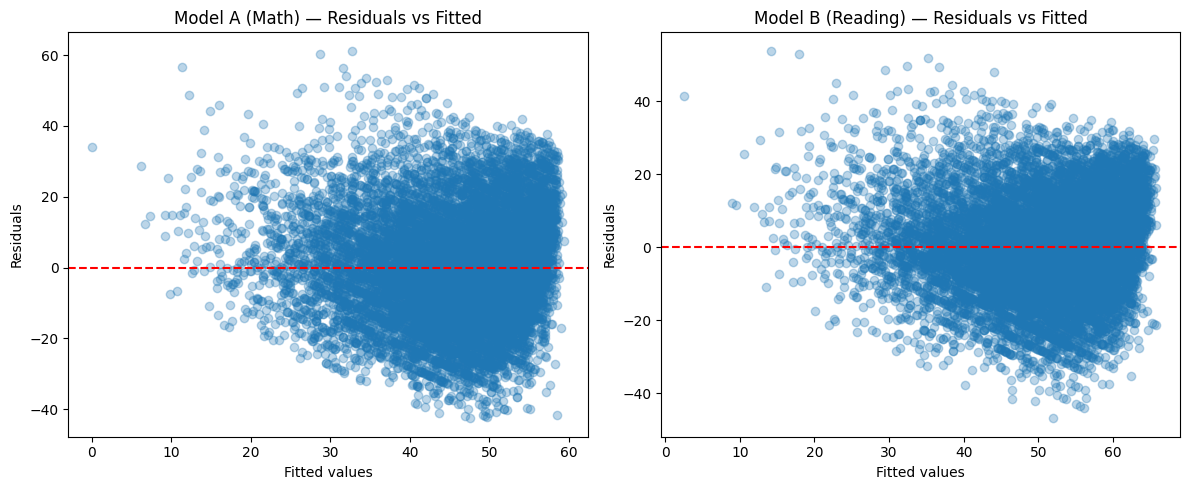

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(model_a.fittedvalues, model_a.resid, alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Model A (Math) — Residuals vs Fitted')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')

axes[1].scatter(model_b.fittedvalues, model_b.resid, alpha=0.3)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Model B (Reading) — Residuals vs Fitted')
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

**Residual-plot result.** Both models show a reasonably even scatter around zero and no strong funnel pattern, so heteroscedasticity is not a major concern. Mild non-normality in the model summaries is not disqualifying with nearly 12,000 observations. The baseline models are suitable foundations, but their different average spending results raise a sharper question: is the spending relationship constant across all districts?


## Extending the baseline: does the relationship differ by context?

The baseline models estimate a single average spending relationship for all districts. Next, test two possible sources of variation:

1. **Interaction effect:** Does spending's association with proficiency change as poverty changes?
2. **Cluster-specific regression:** Does that relationship differ across the district archetypes identified in clustering?


**Load cluster labels.** Load the k=3 cluster labels created in the clustering notebook. They will be used later to test the regression relationship within each district archetype.


In [24]:
df_cluster = pd.read_csv('../datasets/district_data_with_clusters.csv',dtype={'LEAID': str,'FIPST':str,'SCHLEV':str})
print(df_cluster.shape)
print(df_cluster['cluster'].value_counts())

(12768, 24)
cluster
1    6789
0    5945
2      34
Name: count, dtype: int64


**Cluster-label check.** The clustering output contains all 12,768 districts: 5,945 in Cluster 0, 6,789 in Cluster 1, and 34 mega-districts in Cluster 2. The labels are available for the later merge.


**Interaction regression: spending x poverty.** The baseline models average together low- and high-poverty districts. Add a spending-by-poverty interaction to test whether the spending relationship changes with poverty level. Variables are centered first so the interaction is interpretable and does not create artificial collinearity.


In [25]:
# WHY (interaction term): The baseline models estimate one average spending effect.
# Test whether that relationship becomes stronger or weaker as poverty changes.
#
# WHY (centering): Centering before multiplying reduces artificial collinearity
# and makes the main effects interpretable at the average poverty rate.

df_regression['spending_centered'] = df_regression['per_pupil_exp_capped'] - df_regression['per_pupil_exp_capped'].mean()
df_regression['poverty_centered'] = df_regression['poverty_rate'] - df_regression['poverty_rate'].mean()
df_regression['spending_x_poverty_centered'] = df_regression['spending_centered'] * df_regression['poverty_centered']

X_a2c = df_regression[['spending_centered', 'poverty_centered', 'spending_x_poverty_centered']]
X_a2c = sm.add_constant(X_a2c)
y_a2c = df_regression['PCTPROF_MTH_clean']
model_a2c = sm.OLS(y_a2c, X_a2c, missing='drop').fit()
print("=== MODEL A2 (Math, centered interaction) ===")
print(model_a2c.summary())

X_b2c = df_regression[['spending_centered', 'poverty_centered', 'spending_x_poverty_centered']]
X_b2c = sm.add_constant(X_b2c)
y_b2c = df_regression['PCTPROF_RLA_clean']
model_b2c = sm.OLS(y_b2c, X_b2c, missing='drop').fit()
print("\n=== MODEL B2 (Reading, centered interaction) ===")
print(model_b2c.summary())

=== MODEL A2 (Math, centered interaction) ===
                            OLS Regression Results                            
Dep. Variable:      PCTPROF_MTH_clean   R-squared:                       0.255
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     1367.
Date:                Thu, 13 Aug 2026   Prob (F-statistic):               0.00
Time:                        13:37:44   Log-Likelihood:                -49603.
No. Observations:               11984   AIC:                         9.921e+04
Df Residuals:                   11980   BIC:                         9.924e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

**Interaction-model result.** The interaction term is negative and significant in both models (p < 0.001). Spending is positively related to proficiency only in relatively low-poverty districts (below about 13% poverty); as poverty rises, that relationship weakens and becomes negative. This explains why a single whole-sample spending coefficient is incomplete.


**Merge regression data with cluster labels.** To test whether the interaction pattern also appears across district archetypes, merge the cluster labels into the same filtered and capped regression dataset using `LEAID`.


In [26]:
df_regression_clustered = df_regression.merge(
    df_cluster[['LEAID', 'cluster']], on='LEAID', how='inner'
)

print(f"Matched rows: {df_regression_clustered.shape[0]} out of {df_regression.shape[0]}")
print(df_regression_clustered['cluster'].value_counts())

Matched rows: 11984 out of 11984
cluster
1    6338
0    5612
2      34
Name: count, dtype: int64


**Merge result.** All 11,984 regression districts match a cluster label: 5,612 in Cluster 0, 6,338 in Cluster 1, and 34 in Cluster 2. The filtered regression sample is ready for like-for-like cluster comparisons.


**Cluster-specific math regressions.** Run the math regression separately within each cluster. If the whole-sample interaction is meaningful, the spending coefficients should differ by district archetype rather than remain constant.


In [27]:
for c in sorted(df_regression_clustered['cluster'].unique()):
    subset = df_regression_clustered[df_regression_clustered['cluster'] == c]
    X_c = sm.add_constant(subset[['per_pupil_exp_capped', 'poverty_rate']])
    y_c = subset['PCTPROF_MTH_clean']
    model_c = sm.OLS(y_c, X_c, missing='drop').fit()
    
    print(f"\n=== Cluster {c} (n={subset.shape[0]}) — Math proficiency ===")
    print(f"Spending coef: {model_c.params['per_pupil_exp_capped']:.6f}, p-value: {model_c.pvalues['per_pupil_exp_capped']:.4f}")
    print(f"Poverty coef: {model_c.params['poverty_rate']:.6f}, p-value: {model_c.pvalues['poverty_rate']:.4f}")
    print(f"R-squared: {model_c.rsquared:.4f}")


=== Cluster 0 (n=5612) — Math proficiency ===
Spending coef: -0.000106, p-value: 0.0000
Poverty coef: -0.242142, p-value: 0.0000
R-squared: 0.0124

=== Cluster 1 (n=6338) — Math proficiency ===
Spending coef: -0.000380, p-value: 0.0000
Poverty coef: -0.122685, p-value: 0.0000
R-squared: 0.0442

=== Cluster 2 (n=34) — Math proficiency ===
Spending coef: -0.001379, p-value: 0.0272
Poverty coef: -1.000308, p-value: 0.0058
R-squared: 0.3453


In [ ]:
# WHY: residuals tell us which districts scored better/worse than 
# their spending+poverty would predict — this identifies the specific 
# "outlier" districts worth highlighting in the dashboard, not just 
# the average pattern from the regression coefficients.
#
# model_b was fit with sm.add_constant() added to X_b, so predict() 
# needs that same 3-column structure (const, per_pupil_exp_capped, 
# poverty_rate) — passing only 2 columns causes a shape mismatch.

X_predict = df_regression[['per_pupil_exp_capped', 'poverty_rate']]
X_predict = sm.add_constant(X_predict)

df_regression['predicted_reading'] = model_b.predict(X_predict)
df_regression['residual_reading'] = df_regression['PCTPROF_RLA_clean'] - df_regression['predicted_reading']

# Positive residual = overperforming (scored higher than predicted)
# Negative residual = underperforming (scored lower than predicted)

# Sanity check before exporting
print("Top 5 overperformers (reading):")
print(df_regression.nlargest(5, 'residual_reading')[['LEANM', 'STNAME', 'per_pupil_exp', 'poverty_rate', 'PCTPROF_RLA_clean', 'predicted_reading', 'residual_reading']])

print("\nTop 5 underperformers (reading):")
print(df_regression.nsmallest(5, 'residual_reading')[['LEANM', 'STNAME', 'per_pupil_exp', 'poverty_rate', 'PCTPROF_RLA_clean', 'predicted_reading', 'residual_reading']])



Top 5 overperformers (reading):


                            LEANM    STNAME  per_pupil_exp  poverty_rate  \
10553                  KNIPPA ISD     TEXAS   10471.739130     52.127660   
3784   East Bernstadt Independent  KENTUCKY   11536.630037     48.322148   
5736                 RICHLAND R-I  MISSOURI   14503.597122     31.063830   
8061            Steubenville City      OHIO   11643.556600     33.719314   
11214           WISE CO PBLC SCHS  VIRGINIA   10537.098175     29.379662   

       PCTPROF_RLA_clean  predicted_reading  residual_reading  
10553               68.0          14.124860         53.875140  
3784                71.0          17.963128         53.036872  
5736                87.0          35.251855         51.748145  
8061                82.0          32.439225         49.560775  
11214               86.0          36.669010         49.330990  

Top 5 underperformers (reading):
                   LEANM        STNAME  per_pupil_exp  poverty_rate  \
9006              WYNONA      OKLAHOMA   15134.615385

In [29]:
# WHY: same logic as reading — compute predicted math proficiency and 
# residuals so math overperformers/underperformers can be identified too,
# not just reading.

X_predict_math = df_regression[['per_pupil_exp_capped', 'poverty_rate']]
X_predict_math = sm.add_constant(X_predict_math)

df_regression['predicted_math'] = model_a.predict(X_predict_math)
df_regression['residual_math'] = df_regression['PCTPROF_MTH_clean'] - df_regression['predicted_math']

print("Top 5 overperformers (math):")
print(df_regression.nlargest(5, 'residual_math')[['LEANM', 'STNAME', 'per_pupil_exp', 'poverty_rate', 'PCTPROF_MTH_clean', 'predicted_math', 'residual_math']])

print("\nTop 5 underperformers (math):")
print(df_regression.nsmallest(5, 'residual_math')[['LEANM', 'STNAME', 'per_pupil_exp', 'poverty_rate', 'PCTPROF_MTH_clean', 'predicted_math', 'residual_math']])

Top 5 overperformers (math):
                          LEANM    STNAME  per_pupil_exp  poverty_rate  \
11214         WISE CO PBLC SCHS  VIRGINIA   10537.098175     29.379662   
8061          Steubenville City      OHIO   11643.556600     33.719314   
10553                KNIPPA ISD     TEXAS   10471.739130     52.127660   
11131      GALAX CITY PBLC SCHS  VIRGINIA   11781.983346     30.649588   
11162  MECKLENBURG CO PBLC SCHS  VIRGINIA   13659.074733     30.180608   

       PCTPROF_MTH_clean  predicted_math  residual_math  
11214               94.0       32.766956      61.233044  
8061                89.0       28.642128      60.357872  
10553               68.0       11.293977      56.706023  
11131               88.0       31.536506      56.463494  
11162               86.0       31.931571      54.068429  

Top 5 underperformers (math):
                 LEANM    STNAME  per_pupil_exp  poverty_rate  \
5873         Arlee H S   MONTANA   18717.741935     13.461538   
8650             

In [31]:
export_cols = ['LEAID', 'LEANM', 'STNAME', 'per_pupil_exp', 'poverty_rate', 
               'PCTPROF_RLA_clean', 'predicted_reading', 'residual_reading',
               'PCTPROF_MTH_clean', 'predicted_math', 'residual_math']

df_regression[export_cols].to_csv('../datasets/district_residuals.csv', index=False)

**Cluster-regression result.** The negative spending association grows from Cluster 0 (-0.000106) to Cluster 1 (-0.000380) to Cluster 2 (-0.001379), consistent with the interaction result. Within-cluster R-squared values are lower for Clusters 0 and 1 because similar districts leave less variation to explain. **Caution:** Cluster 2 has only 34 districts, so its estimates are suggestive rather than conclusive.


## Final insights and recommended decisions

### What the final analysis shows

- **Poverty is the most consistent factor across the analysis.** It is strongly negative in both whole-sample models and remains statistically significant in all three cluster-specific math regressions. The proficiency gap is therefore not explained by district spending alone.
- **More total spending is not a universal solution.** After controlling for poverty, spending has no significant average association with math proficiency and only a very small positive association with reading. Within every cluster, the spending coefficient is negative; this is an association, not proof that spending harms outcomes.
- **The spending relationship depends on context.** The interaction models show that the relationship weakens as poverty rises. In lower-poverty districts, additional spending can be positively associated with proficiency; in higher-poverty districts, total spending alone is not associated with better outcomes.
- **District archetypes need different responses.** Cluster 0 is low-poverty and high-performing; Cluster 1 is high-poverty and low-performing; Cluster 2 is made up of very large mega-districts. The same budget policy should not be applied identically to all three groups.

### Decisions supported by these findings

| District group | Evidence from the analysis | Recommended decision |
|---|---|---|
| **Cluster 0: low poverty, high performance** | Outcomes are already comparatively strong, although poverty still has a significant negative association within this group. | Maintain core funding and direct any new funds toward tested instructional improvements or enrichment. Require outcome monitoring rather than assuming a general budget increase will improve proficiency. |
| **Cluster 1: high poverty, low performance** | This group has the weakest outcomes; poverty remains significant, while higher total spending by itself is not associated with better math results. | Prioritize poverty-responsive funding: tutoring, attendance support, counseling, nutrition, family engagement, and teacher recruitment/retention. Additional money should be tied to specific interventions and measured outcomes, not distributed as unrestricted general spending alone. |
| **Cluster 2: mega-districts** | These districts have the lowest per-pupil spending and a distinct pattern, but the group has only 34 districts. | Do not make broad policy changes from this coefficient alone. Conduct a separate operational and spending-category review, then test targeted pilots before scaling them across large urban systems. |

### Overall funding decision

Use a **needs-based funding approach**, not a blanket per-pupil increase. Give greater priority to high-poverty districts, but attach funding to specific student supports and instructional uses. Track proficiency, attendance, staffing, and service delivery after implementation. The next analytical step is to split total spending into instructional, support-service, and capital categories to identify which uses of funding are most strongly associated with improved outcomes.

> **Important caution:** These regressions show relationships after controlling for poverty; they do not prove that a funding change will cause a particular outcome. Policy changes should therefore be implemented with monitoring or pilot evaluation.
